<a href="https://colab.research.google.com/github/gayakarapetyan/PythonCourseH2/blob/main/Session3/02_Flood_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Flood Detection, Prediction & Forecasting
**Environmental Statistics and Artificial Intelligence — Practical Block 3, Part 2**

In Part 1 we predicted *numbers* (regression). Now we predict *categories* — and we do it through
one real **floods**.

our workflow:
- **Detection** — *is it flooding right now?* (classify the current state)
- **Prediction** — *do these conditions mean a flood?* (learn the rainfall→flood link)
- **Forecasting** — *will it flood tomorrow?* (predict the future from the past)

…and then we **zoom out** to map flood-prone catchments across all of Germany (clustering).


**Our data:** daily discharge and weather for one German catchment (the CAMELS-DE time series), then
the catchment-attributes table for the Germany-wide map at the end.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.dpi"] = 90

# one catchment, 10 years of daily data
## Your path here!!!
ts = (pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PythonCourse/Session3/Data/teaching_data/timeseries_DE110260.csv", parse_dates=["date"])
        .sort_values("date").reset_index(drop=True))
print(ts.shape)
ts[["date", "precipitation_mean", "temperature_mean", "discharge_spec_obs"]].head()

(3653, 8)


,date,precipitation_mean,temperature_mean,discharge_spec_obs
0,2011-01-01,0.00,0.61,0.679
1,2011-01-02,0.00,4.03,0.640
2,2011-01-03,0.00,3.64,0.595
3,2011-01-04,0.00,-0.90,0.565
4,2011-01-05,1.48,-0.37,0.551


---
# Part A — Detecting floods on a river

## What is a "flood day"?

There's no discharge column saying "flood: yes/no". we have to *define* it. A common, simple
definition: a flood day is one where discharge is unusually high — say, in the **top 10%** of all
days. We use the 90th percentile of discharge as the threshold.

In [ ]:
threshold = ts["discharge_spec_obs"].quantile(0.90)   # top 10% of days
ts["flood"] = (ts["discharge_spec_obs"] >= threshold).astype(int)   # 1 = flood, 0 = not

print(f"flood threshold: {threshold:.2f} mm/d")
print(f"flood days: {ts['flood'].sum()} out of {len(ts)} "
      f"({100*ts['flood'].mean():.1f}% of all days)")

flood threshold: 1.24 mm/d
flood days: 366 out of 3653 (10.0% of all days)


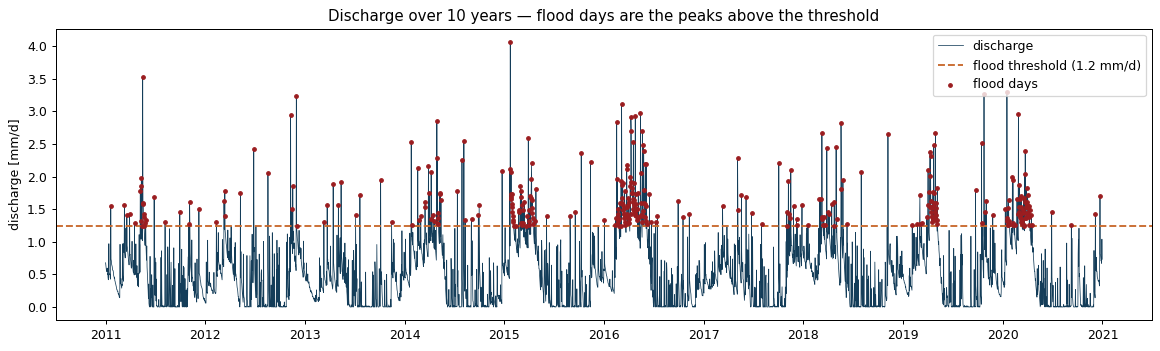

In [ ]:
#lets plot and mark the flood days
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts["date"], ts["discharge_spec_obs"], color="#143d59", lw=0.6, label="discharge")
ax.axhline(threshold, color="#c96a2e", ls="--", lw=1.5, label=f"flood threshold ({threshold:.1f} mm/d)")
flood_days = ts[ts["flood"] == 1]
ax.scatter(flood_days["date"], flood_days["discharge_spec_obs"],
           color="#9b1d20", s=8, zorder=3, label="flood days")
ax.set_ylabel("discharge [mm/d]"); ax.legend(loc="upper right")
ax.set_title("Discharge over 10 years — flood days are the peaks above the threshold")
plt.tight_layout(); plt.show()

## Setting up the classification

Same as regression: features `X`, target `y`, train/test split. For **detection**, we ask:
*can we recognize a flood from today's weather?* So our features are today's precipitation and
temperature, and the target is the flood label.

`train_test_split` you already know. One new piece: **`stratify=y`** — this keeps the same
proportion of flood days in both the training and test sets. With rare events, that's important;
otherwise the test set might get very few floods by chance.

In [ ]:
from sklearn.model_selection import train_test_split

features = ["precipitation_mean", "temperature_mean"]
X = ts[features]
y = ts["flood"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)   # stratify keeps flood % equal

print("training days:", len(X_train), " test days:", len(X_test))
print("floods in test set:", y_test.sum())

training days: 2557  test days: 1096
floods in test set: 110


## Logistic Regression

Despite its name, **logistic regression is a classification method** (the "regression" is historical).
Instead of predicting a number, it
predicts the **probability** that something belongs to a class, by squashing a weighted sum of the
features through an S-shaped curve into the range 0–1. If the probability is above 0.5, it predicts
"flood."


> **New function — `class_weight="balanced"`.** Because floods are rare (10%), `class_weight="balanced"` tells the model
> *"treat the rare flood days as important"* — it pays more attention to catching them.

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

accuracy = logreg.score(X_test, y_test)
print(f"accuracy on test set: {accuracy:.3f}")

accuracy on test set: 0.822


**Accuracy** = the fraction of days the model labelled correctly (flood or not). Here it's high —
but for rare events, **accuracy alone is dangerously misleading**, and the next step shows why. We
need a better way to look at the results.

## The right way to check a classifier: the confusion matrix

For regression we used the predicted-vs-observed plot. For classification, the equivalent is the
**confusion matrix** — a small grid showing four numbers:

|  | predicted: not flood | predicted: flood |
|---|---|---|
| **actually not flood** | ✅ correct (true negative) | ❌ false alarm (false positive) |
| **actually flood** | ❌ **missed flood** (false negative) | ✅ caught flood (true positive) |

The two ✅ boxes are correct predictions; the two ❌ boxes are mistakes. The **bottom-left box is the
dangerous one** — a real flood the model missed. `scikit-learn` computes and plots this for us.


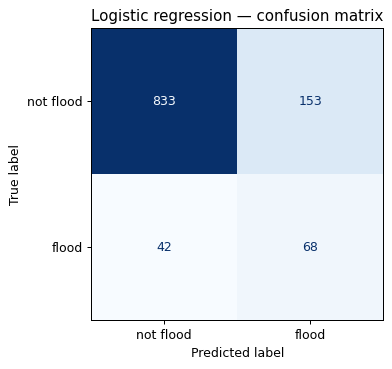

caught floods (correct)  : 68
missed floods (dangerous): 42
false alarms             : 153


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = logreg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["not flood", "flood"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic regression — confusion matrix")
plt.tight_layout(); plt.show()

# read the four numbers
tn, fp, fn, tp = cm.ravel()
print(f"caught floods (correct)  : {tp}")
print(f"missed floods (dangerous): {fn}")
print(f"false alarms             : {fp}")

## Accuracy lies

Here's the crucial lesson. Imagine a model that **always** predicts "not flood." On our data it would
be ~90% accurate (because 90% of days really aren't floods) — yet it would catch **zero** floods and
be completely useless as a warning system. **High accuracy can hide total failure on the thing you
care about.**

So for flood warning we care less about overall accuracy and more about: *of all the real floods, how
many did we catch?* That's called **recall**.

> **Recall** = (floods caught) / (all real floods). A recall of 0.8 means we caught 80% of the actual
> floods. For a warning system, high recall is what keeps people safe — a missed flood is far worse
> than a false alarm.

> **New function — `recall_score`.**

In [ ]:
from sklearn.metrics import recall_score, precision_score

print(f"accuracy: {accuracy:.3f}   <- looks good...")
print(f"recall  : {recall_score(y_test, y_pred):.3f}   <- ...but THIS is what matters for warnings")
print(f"          (we caught {tp} of {tp+fn} real floods)")

accuracy: 0.822   <- looks good...
recall  : 0.618   <- ...but THIS is what matters for warnings
          (we caught 68 of 110 real floods)


**This is the single most important idea in classification:** choose your metric to match what
matters. For floods, that's recall (catch the floods). For something where false alarms are costly,
you'd weigh **precision** (of the alarms we raised, how many were real?) more heavily.

### Task A.1
Re-train the logistic regression **without** `class_weight="balanced"` (just
`LogisticRegression(max_iter=1000)`). Print its accuracy and recall, and show its confusion matrix.
What happens to accuracy? What happens to the number of floods caught? Which model would you rather
deploy as a flood warning?

In [ ]:
# Your code here


## The Decision Tree model

A **decision tree** classifies by asking a series of yes/no questions about the features — like a
flowchart. "Is precipitation above 8 mm? If yes, is temperature below 5°C? …" — following the
branches leads to a flood / not-flood decision. Water engineers love trees because **you can read the
rules** and check they make physical sense.

>  `DecisionTreeClassifier` (the model) and `plot_tree` (draws the flowchart).
> `max_depth=4` limits the tree to 4 questions deep so it stays readable (and doesn't overfit).

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=0, class_weight="balanced")
tree.fit(X_train, y_train)

print(f"accuracy: {tree.score(X_test, y_test):.3f}")
print(f"recall: {recall_score(y_test, tree.predict(X_test)):.3f}")

accuracy: 0.875
recall: 0.591


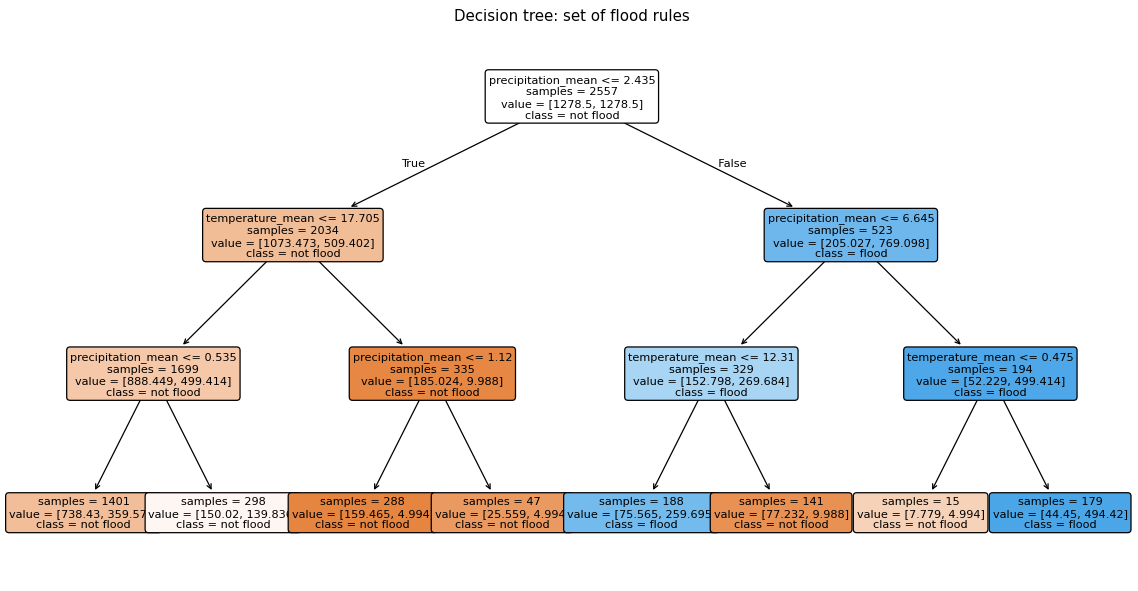

In [ ]:
# draw the flowchart — each box is a yes/no question
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=features, class_names=["not flood", "flood"],
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("Decision tree: set of flood rules")
plt.show()

The coloured leaves show the final decision. This
readability is why trees are popular in environmental science — a reviewer can verify the logic.

Let's check its confusion matrix too, the same way as before.

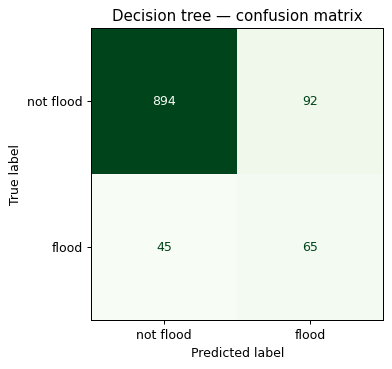

In [ ]:
cm_tree = confusion_matrix(y_test, tree.predict(X_test))
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm_tree, display_labels=["not flood", "flood"]).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Decision tree — confusion matrix")
plt.tight_layout(); plt.show()

## Random Forest

A single tree is easy to read but a bit unstable. A **random forest** grows hundreds of different
trees on random slices of the data and lets them *vote* — this averaging makes it more accurate and
robust.

accuracy: 0.889
recall  : 0.400


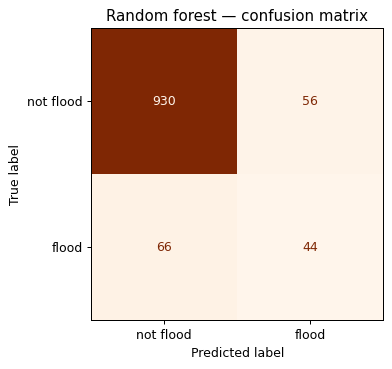

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced")
forest.fit(X_train, y_train)

print(f"accuracy: {forest.score(X_test, y_test):.3f}")
print(f"recall: {recall_score(y_test, forest.predict(X_test)):.3f}")

cm_rf = confusion_matrix(y_test, forest.predict(X_test))
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(cm_rf, display_labels=["not flood", "flood"]).plot(
    ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Random forest — confusion matrix")
plt.tight_layout(); plt.show()

Compare the three confusion matrices you've now made. You'll often find the forest has the
*highest accuracy* but doesn't necessarily catch the *most floods* — a perfect illustration of why we
look past accuracy. **Match the model and the metric to the goal.**

### Task A.2
Print the `recall` for all three models (logistic regression, tree, forest) side by side. Which model
catches the most floods? Is it the same one that has the highest accuracy? What does that tell you?

In [ ]:
# Your code here


---
# Part B — Predicting floods from rainfall build-up

So far we detected floods from *today's* weather. But floods rarely come from a single day's rain —
they build up from **days of accumulated rainfall** soaking the ground until the river can't take
more. Let's give the model that information.

In [ ]:
# accumulated rainfall over sliding windows
for window in [3, 7, 14]:
    ts[f"precip_{window}day"] = ts["precipitation_mean"].rolling(window).sum()

# the first 14 days have no full window -> drop those rows
ts_fe = ts.dropna().reset_index(drop=True)

ts_fe[["date", "precipitation_mean", "precip_3day", "precip_7day", "precip_14day"]].head()

,date,precipitation_mean,precip_3day,precip_7day,precip_14day
0,2011-01-14,0.0,9.11,13.10,15.33
1,2011-01-15,0.0,5.09,9.12,15.33
2,2011-01-16,0.0,0.00,9.12,15.33
3,2011-01-17,0.0,0.00,9.11,15.33
4,2011-01-18,0.0,0.00,9.11,15.33


Let's predict floods using **today's rain plus the accumulated
rainfall**, and see if catching floods improves.

In [ ]:
features2 = ["precipitation_mean", "precip_3day", "precip_7day", "precip_14day", "temperature_mean"]
X2 = ts_fe[features2]
y2 = ts_fe["flood"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2)

# same decision tree as before, now with the richer features
tree2 = DecisionTreeClassifier(max_depth=4, random_state=0, class_weight="balanced")
tree2.fit(X2_train, y2_train)

print("DETECTION (today only)      recall was around 0.68")
print(f"PREDICTION (with build-up)  recall = {recall_score(y2_test, tree2.predict(X2_test)):.3f}")
print("-> giving the model the rainfall history helps it catch more floods!")

DETECTION (today only)      recall was around 0.68
PREDICTION (with build-up)  recall = 0.800
-> giving the model the rainfall history helps it catch more floods!


Adding the accumulated-rainfall features lets the model catch noticeably more floods — because
it now "sees" the wet spell building up, not just one day. **Better features beat fancier models.**

Which features matter most? The random forest can tell us — and the answer is a real hydrological
insight.

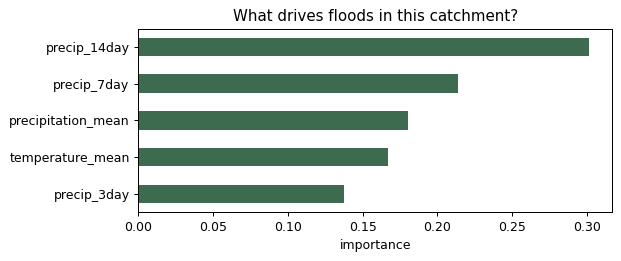

precip_3day           0.138
temperature_mean      0.167
precipitation_mean    0.180
precip_7day           0.214
precip_14day          0.302
dtype: float64


In [ ]:
forest2 = RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced")
forest2.fit(X2_train, y2_train)

importances = pd.Series(forest2.feature_importances_, index=features2).sort_values()
importances.plot.barh(color="#3d6b4f", figsize=(7, 3))
plt.xlabel("importance"); plt.title("What drives floods in this catchment?")
plt.tight_layout(); plt.show()

print(importances.round(3))

Notice the **longer accumulation windows (7-day, 14-day) often rank highest** — telling us that
in this catchment, floods are driven more by *sustained wet spells* than by a single day's rain.
Different
catchments would give different answers (a small steep catchment might react to a single day).


### Task B.1
Add an even longer window, `precip_30day`, to the features and refit the random forest. Does the
30-day total rank high? What would a high 30-day importance tell you about the catchment's memory?

In [ ]:
# Your code here


---
# Part C — Forecasting tomorrow's flood (a glimpse ahead)

Detection and prediction both ask about the *current* day. **Forecasting** is harder: *will it flood
**tomorrow**?* We'd predict day *t+1* using information up to day *t*.

There's a crucial rule when working with time:


Let's set up a proper forecasting target and a *time-based* split, just to see the idea.

In [ ]:
# target: does a flood happen TOMORROW? (shift the flood column back by one day)
ts_fe["flood_tomorrow"] = ts_fe["flood"].shift(-1)
ts_fc = ts_fe.dropna().reset_index(drop=True)
ts_fc["flood_tomorrow"] = ts_fc["flood_tomorrow"].astype(int)

# TIME-based split: first 8 years train, last 2 years test (NOT random!)
split_date = "2019-01-01"
train_mask = ts_fc["date"] < split_date

Xf_train = ts_fc.loc[train_mask, features2]
Xf_test  = ts_fc.loc[~train_mask, features2]
yf_train = ts_fc.loc[train_mask, "flood_tomorrow"]
yf_test  = ts_fc.loc[~train_mask, "flood_tomorrow"]

print(f"train: up to {split_date} ({len(Xf_train)} days)")
print(f"test : from {split_date} ({len(Xf_test)} days)")

train: up to 2019-01-01 (2909 days)
test : from 2019-01-01 (730 days)


In [ ]:
forest_fc = RandomForestClassifier(n_estimators=200, random_state=0, class_weight="balanced")
forest_fc.fit(Xf_train, yf_train)
print(f"forecasting tomorrow's flood — recall = {recall_score(yf_test, forest_fc.predict(Xf_test)):.3f}")

forecasting tomorrow's flood — recall = 0.029


Forecasting the *future* is genuinely much harder than detecting the present — notice the recall
drops sharply. Predicting a rare event a full day ahead, from a few hand-made features, is near the
limit of what these simple models can do (a near-zero recall here means it's barely catching
tomorrow's floods — not a bug, just a genuinely hard problem). This is exactly the kind of task
**neural networks with memory (LSTMs)** are built for, because they learn from the *whole sequence* of
recent days rather than a few summary features.

> **This is our bridge to the next session.** In the neural-network block we'll build an LSTM that
> reads the whole recent history of a catchment and forecasts its discharge — the natural next step
> beyond what we've done here. Keep this cliffhanger in mind!

---
# Part D — Mapping flood-prone catchments across Germany (clustering)

So far: one river. Now let's **zoom out to all 1,582 German catchments** and ask a different kind of
question — one with *no labels at all*:

> *Which catchments behave similarly when it comes to flooding?*

We don't tell the computer the answer; we let it **find groups** of similar catchments by itself.
This is **clustering** — unsupervised learning. The payoff is a flood-behaviour map of Germany,
directly useful for flood-risk assessment.

We describe each catchment by its **flood-related behaviour**: how often it has high flows, how
"flashy" it is (sharp peaks vs smooth), and its baseflow character.

In [ ]:
# the catchment attributes table (one row per catchment)
catch = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PythonCourse/Session3/Data/teaching_data/camels_de_attributes_teaching.csv")

flood_behaviour = ["high_q_freq", "slope_fdc", "baseflow_index", "runoff_ratio"]
print("describing each catchment by its flood behaviour:")
print("  high_q_freq    = how many days per year have high flow")
print("  slope_fdc      = how 'flashy' the river is (steep = flashy)")
print("  baseflow_index = how groundwater-fed it is (high = steady)")
print("  runoff_ratio   = fraction of rain that becomes streamflow")
catch[flood_behaviour].describe().round(2)

describing each catchment by its flood behaviour:
  high_q_freq    = how many days per year have high flow
  slope_fdc      = how 'flashy' the river is (steep = flashy)
  baseflow_index = how groundwater-fed it is (high = steady)
  runoff_ratio   = fraction of rain that becomes streamflow


,high_q_freq,slope_fdc,baseflow_index,runoff_ratio
count,1582.00,1582.00,1582.00,1582.00
mean,8.23,2.02,0.70,0.44
std,4.12,0.73,0.11,0.12
min,0.50,0.40,0.37,0.14
25%,5.20,1.53,0.63,0.35
50%,8.14,2.03,0.70,0.42
75%,11.10,2.50,0.78,0.50
max,23.98,4.31,0.97,0.95


## D1. k-means clustering

The most common clustering method is **k-means**. You tell it how many groups (*k*) you want, and it
finds *k* cluster centres and assigns each catchment to its nearest one — grouping similar catchments
together.

> **New function — `KMeans`.** And as always with distance-based methods, we **standardize first**
> (`StandardScaler`) so every feature is on the same scale.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Xc = StandardScaler().fit_transform(catch[flood_behaviour])   # standardize

km = KMeans(n_clusters=3, n_init=10, random_state=0)
catch["cluster"] = km.fit_predict(Xc)

print("catchments per cluster:")
print(catch["cluster"].value_counts().sort_index())

catchments per cluster:
cluster
0    367
1    668
2    547
Name: count, dtype: int64


## D2. How many groups? The silhouette score

We chose k=3 — but how do we know that's reasonable? The **silhouette score** measures how
well-separated the clusters are (higher = better, range −1 to +1). We try several k values and look.

>  **New function — `silhouette_score`.**

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xc)
    print(f"k = {k}:  silhouette = {silhouette_score(Xc, labels):.3f}")

k = 2:  silhouette = 0.227
k = 3:  silhouette = 0.220
k = 4:  silhouette = 0.205
k = 5:  silhouette = 0.189
k = 6:  silhouette = 0.188


The score guides you, but the "best" k also depends on your question — a few broad flood types,
or many fine ones? We keep **k=3** here for a clear, interpretable story (a common, defensible choice).

## D3. What do the clusters mean? The flood fingerprint

Clusters are just numbers until we *characterize* them. We look at the median behaviour of each
cluster — its "fingerprint" — and give it a plain-language name.

Median flood-behaviour per cluster:
         high_q_freq  slope_fdc  baseflow_index  runoff_ratio
cluster                                                      
0               9.35       1.80            0.77          0.59
1              10.14       2.41            0.63          0.38
2               4.84       1.68            0.75          0.39



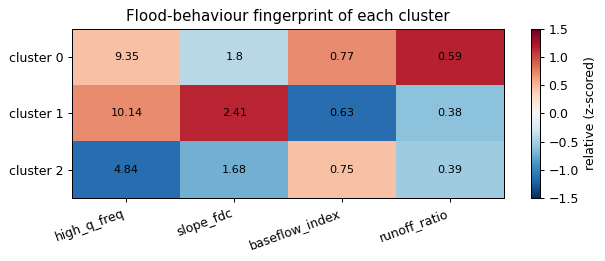

In [ ]:
fingerprint = catch.groupby("cluster")[flood_behaviour].median().round(2)
print("Median flood-behaviour per cluster:")
print(fingerprint)
print()

# a heatmap makes the differences pop (z-scored so colours are comparable)
fp_z = (fingerprint - fingerprint.mean()) / fingerprint.std()
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(fp_z, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)
ax.set_xticks(range(len(flood_behaviour))); ax.set_xticklabels(flood_behaviour, rotation=20, ha="right")
ax.set_yticks(range(len(fingerprint))); ax.set_yticklabels([f"cluster {i}" for i in fingerprint.index])
for i in range(fingerprint.shape[0]):
    for j in range(fingerprint.shape[1]):
        ax.text(j, i, fingerprint.values[i, j], ha="center", va="center", fontsize=9)
plt.colorbar(im, label="relative (z-scored)")
ax.set_title("Flood-behaviour fingerprint of each cluster")
plt.tight_layout(); plt.show()

Read each row as a flood "personality." For example, a cluster with **high `high_q_freq` and high
`slope_fdc`** is *flashy and flood-prone* — sharp, frequent peaks. A cluster with **high
`baseflow_index` and low `high_q_freq`** is *steady and groundwater-fed* — less flood-prone. You give
each cluster a name from its fingerprint; that interpretation is the scientific payoff.

This is exactly how hydrologists build **flood-risk typologies** — grouping catchments so that
knowledge (and flood models) can be transferred from well-studied rivers to similar, less-studied
ones.

###  Task D.1
Compare the clusters' physical settings: run
`catch.groupby("cluster")[["elev_mean", "aridity", "slope_mean"]].median()`. Do the flashy,
flood-prone catchments tend to sit at higher elevation or steeper terrain? Does the flood behaviour
line up with the landscape?

In [ ]:
# Your code here


---
##  Mini-exercise (20 min): your own flood classifier

Using the single-catchment time series (with the accumulated-rainfall features from Part B):

1. Build features and the flood label (you can change the threshold — try the 95th percentile for
   *bigger* floods, or keep the 90th).
2. Train **logistic regression**, a **decision tree**, and a **random forest** (use
   `class_weight="balanced"`).
3. For each, show the **confusion matrix** and report **recall** (floods caught).
4. Which model would you deploy as a flood-warning system, and why? (Hint: think recall, but also
   how many false alarms you'd tolerate.)
5. **Bonus:** look at the decision tree's `plot_tree` — write down one flood "rule" it learned in
   plain language.

Write 3–4 sentences on what you found and which model you'd trust.

In [ ]:
# Your flood classifier here


---
---
## 🔑 Solutions / hints

<details><summary>Click to expand</summary>

**Task A.1** — without `class_weight="balanced"`:
```python
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
p = lr.predict(X_test)
print("accuracy:", lr.score(X_test, y_test))   # HIGHER (~0.90)
print("recall  :", recall_score(y_test, p))    # but much LOWER — catches almost no floods!
ConfusionMatrixDisplay(confusion_matrix(y_test, p),
    display_labels=["not flood","flood"]).plot(cmap="Blues")
# Lesson: higher accuracy, useless for warnings. The 'balanced' version is what you'd deploy.
```

**Task A.2**
```python
for name, m in [("logreg", logreg), ("tree", tree), ("forest", forest)]:
    print(name, round(recall_score(y_test, m.predict(X_test)), 3))
# The forest often has the highest ACCURACY but NOT the highest recall.
# -> accuracy and "catching floods" are different things.
```

**Task B.1**
```python
ts_fe["precip_30day"] = ts["precipitation_mean"].rolling(30).sum()
# rebuild ts_fe (dropna), refit forest2 with precip_30day added to features2.
# A high 30-day importance => the catchment has long memory (slow, groundwater-driven floods).
```

**Task D.1**
```python
print(catch.groupby("cluster")[["elev_mean","aridity","slope_mean"]].median())
# Typically the flashy/flood-prone cluster sits at higher elevation & steeper slope.
```

**Mini-exercise** — reference approach:
```python
feats = ["precipitation_mean","precip_3day","precip_7day","precip_14day","temperature_mean"]
X = ts_fe[feats]; y = ts_fe["flood"]
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.3,random_state=42,stratify=y)
for name,m in [("logreg",LogisticRegression(max_iter=1000,class_weight="balanced")),
               ("tree",DecisionTreeClassifier(max_depth=4,random_state=0,class_weight="balanced")),
               ("forest",RandomForestClassifier(200,random_state=0,class_weight="balanced"))]:
    m.fit(Xtr,ytr)
    print(name, "recall", round(recall_score(yte, m.predict(Xte)),3))
# Often the tree/logreg catch more floods (higher recall); the forest is more accurate overall.
# A warning system usually favours recall -> but discuss the false-alarm trade-off.
```
</details>

---
###  Notes
- **Data**: CAMELS-DE daily time series (one catchment) + catchment attributes (all 1582).
- **The flood label is a teaching definition** (discharge above a percentile). Real flood definitions
  use gauge-specific warning levels set by agencies.
- **Methods** (all from `scikit-learn`): `LogisticRegression`, `DecisionTreeClassifier`,
  `RandomForestClassifier`, `KMeans`; metrics `confusion_matrix`, `recall_score`, `silhouette_score`.
- **The big lesson**: for rare events like floods, *accuracy hides failure* — choose the metric
  (recall) that matches what matters, and engineer features (rainfall build-up) that match the
  physics.